# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [ ]:
!pip install Levenshtein
!pip install nltk       

In [1]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

d:\home\Documents\Github\human_patterns_exploration


In [2]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")


In [3]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

import pandas as pd
pd.set_option('display.max_rows', None)

import pandas as pd  # Missing import
import Levenshtein

import nltk

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


print("Downloading required NLTK data...")
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') 
nltk.download('wordnet')
nltk.download('omw-1.4') 
print("NLTK data downloaded successfully!")


NLTK data downloaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\cmore\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
IMG_ID = 1
IMG_TYPE = "exp"
llm_provider = "openai"

IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)



In [ ]:


# load img scene description
scene_descr_path = os.path.join(RESULTS_DIR, "SceneDescriptions", f"{llm_provider}_results", f"IMG_{IMG_ID}_{IMG_TYPE}_descr.txt")
image_data.load_scene_description(scene_descr_path)

print(image_data.description)

print("\n\n")

# load masks
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
image_data.load_img_masks( masks_path_dir, part_id="2" )
print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

1. **Scene Overview**:  
   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.

2. **Identified Objects**:  
   - **Washing Machine**: Located on the left side of the image, it has a front-loading door and is white in color.
   - **Dryer**: Positioned next to the washing machine, also white, with a similar front-loading design.
   - **Storage Cabinets**: Above the washing machine and dryer, there are white cabinets with multiple doors, providing storage space.
   - **Desk**: A long, white desk is situated in the center of the image, extending from the washing machine to the right side.
   - **Chair**: A black chair is placed in front of the desk.
   - **Desk Items**: Various items on the desk include colored cones, stationery, a sewing machine, and a few decorative objects.
   - 

In [ ]:

def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)


def disambiguate_overlapping_masks( grouped_df : pd.DataFrame, sim_threshold=0.93):

    # Find and handle lemma duplicates
    plurals = []
    labels_to_remove = set()
    processed_pairs = set() 
    
    lemmatizer = WordNetLemmatizer()
    
    # Compute area for comparison
    grouped_df['area'] = (grouped_df['x_max'] - grouped_df['x_min']) * (grouped_df['y_max'] - grouped_df['y_min'])

    for i in range(len(grouped_df)):
        label1_orig = grouped_df.iloc[i]['label']
        
        # Skip if this label is already marked for removal
        if label1_orig in labels_to_remove:
            continue
            
        # Get the lemmatized version
        label1_lemma = lemmatizer.lemmatize(label1_orig, get_wordnet_pos(label1_orig))
        
        for j in range(i + 1, len(grouped_df)):  # Start from i+1 to avoid self-comparison and duplicates
            label2_orig = grouped_df.iloc[j]['label']
            
            # Skip if this label is already marked for removal
            if label2_orig in labels_to_remove:
                continue
            
            # Create a pair key to avoid processing the same pair twice
            pair_key = tuple(sorted([label1_orig, label2_orig]))
            if pair_key in processed_pairs:
                continue
            processed_pairs.add(pair_key)
            
            # Get the lemmatized version
            label2_lemma = lemmatizer.lemmatize(label2_orig, get_wordnet_pos(label2_orig))
            
            similarity = Levenshtein.jaro_winkler(label1_lemma, label2_lemma)
            
            if (label1_lemma == label2_lemma) or (similarity > sim_threshold):
                
                # Find which label has the smaller area
                area1 = grouped_df.iloc[i]['area']
                area2 = grouped_df.iloc[j]['area']
                
                if area1 > area2:
                    label_to_remove = label1_orig
                    label_to_keep = label2_orig
                else:
                    label_to_remove = label2_orig
                    label_to_keep = label1_orig
                
                labels_to_remove.add(label_to_remove)
                plurals.append((label1_orig, label2_orig, f"kept: {label_to_keep}"))
                
                print(f"  -> Lemma match! Removing '{label_to_remove}', keeping '{label_to_keep}'")

    grouped_df = grouped_df[~grouped_df['label'].isin(labels_to_remove)].reset_index(drop=True)
    
    # Drop the area column as it's no longer needed
    grouped_df.drop(columns=['area'], inplace=True)

    # for debugging
    print(f"\nPlural/duplicate pairs found: {plurals}")

    return grouped_df


def get_scene_masks(image_data, sim_threshold=0.93):

    columns = ["label", "x_min", "x_max", "y_min", "y_max"]
    df_masks = pd.DataFrame(columns=columns)
    
    # Extract mask data
    for indx in range(len(image_data.masks)):
        mask = image_data.masks[indx]
        df_masks.loc[indx] = [mask.most_freq_label, mask.x_min, mask.x_max, mask.y_min, mask.y_max]

    # Order by label alphabetically
    df_masks = df_masks.sort_values(by="label")
    df_masks.reset_index(drop=True, inplace=True)

    # Group by label and take average of coordinates
    grouped_df = df_masks.groupby('label').agg({
        'x_min': 'min', 
        'x_max': 'min', 
        'y_min': 'min', 
        'y_max': 'min'
    }).reset_index()

    # Round coordinates
    for col in ['x_min', 'x_max', 'y_min', 'y_max']:
        grouped_df[col] = grouped_df[col].round(4)
    
    grouped_df = disambiguate_overlapping_masks( grouped_df, sim_threshold=sim_threshold )
    
    print(f"Final unique labels: {sorted(grouped_df['label'].unique())}")
    
    # convert to dictionary where the label is the key
    label_dict = grouped_df.set_index('label').T.to_dict('list')
    
    return label_dict

bbox_dict = get_scene_masks(image_data)


  -> Lemma match! Removing 'slippers', keeping 'slipper'
  -> Lemma match! Removing 'toys', keeping 'toy'

Plural/duplicate pairs found: [('slipper', 'slippers', 'kept: slipper'), ('toy', 'toys', 'kept: toy')]
Final unique labels: ['cabinets', 'cart', 'chair', 'clothes', 'cup', 'cushion', 'desk', 'hamper', 'ironing', 'lamp', 'laundry', 'plant', 'rug', 'shelves', 'shoe', 'slipper', 'sofa', 'table', 'teapot', 'throw', 'toy']


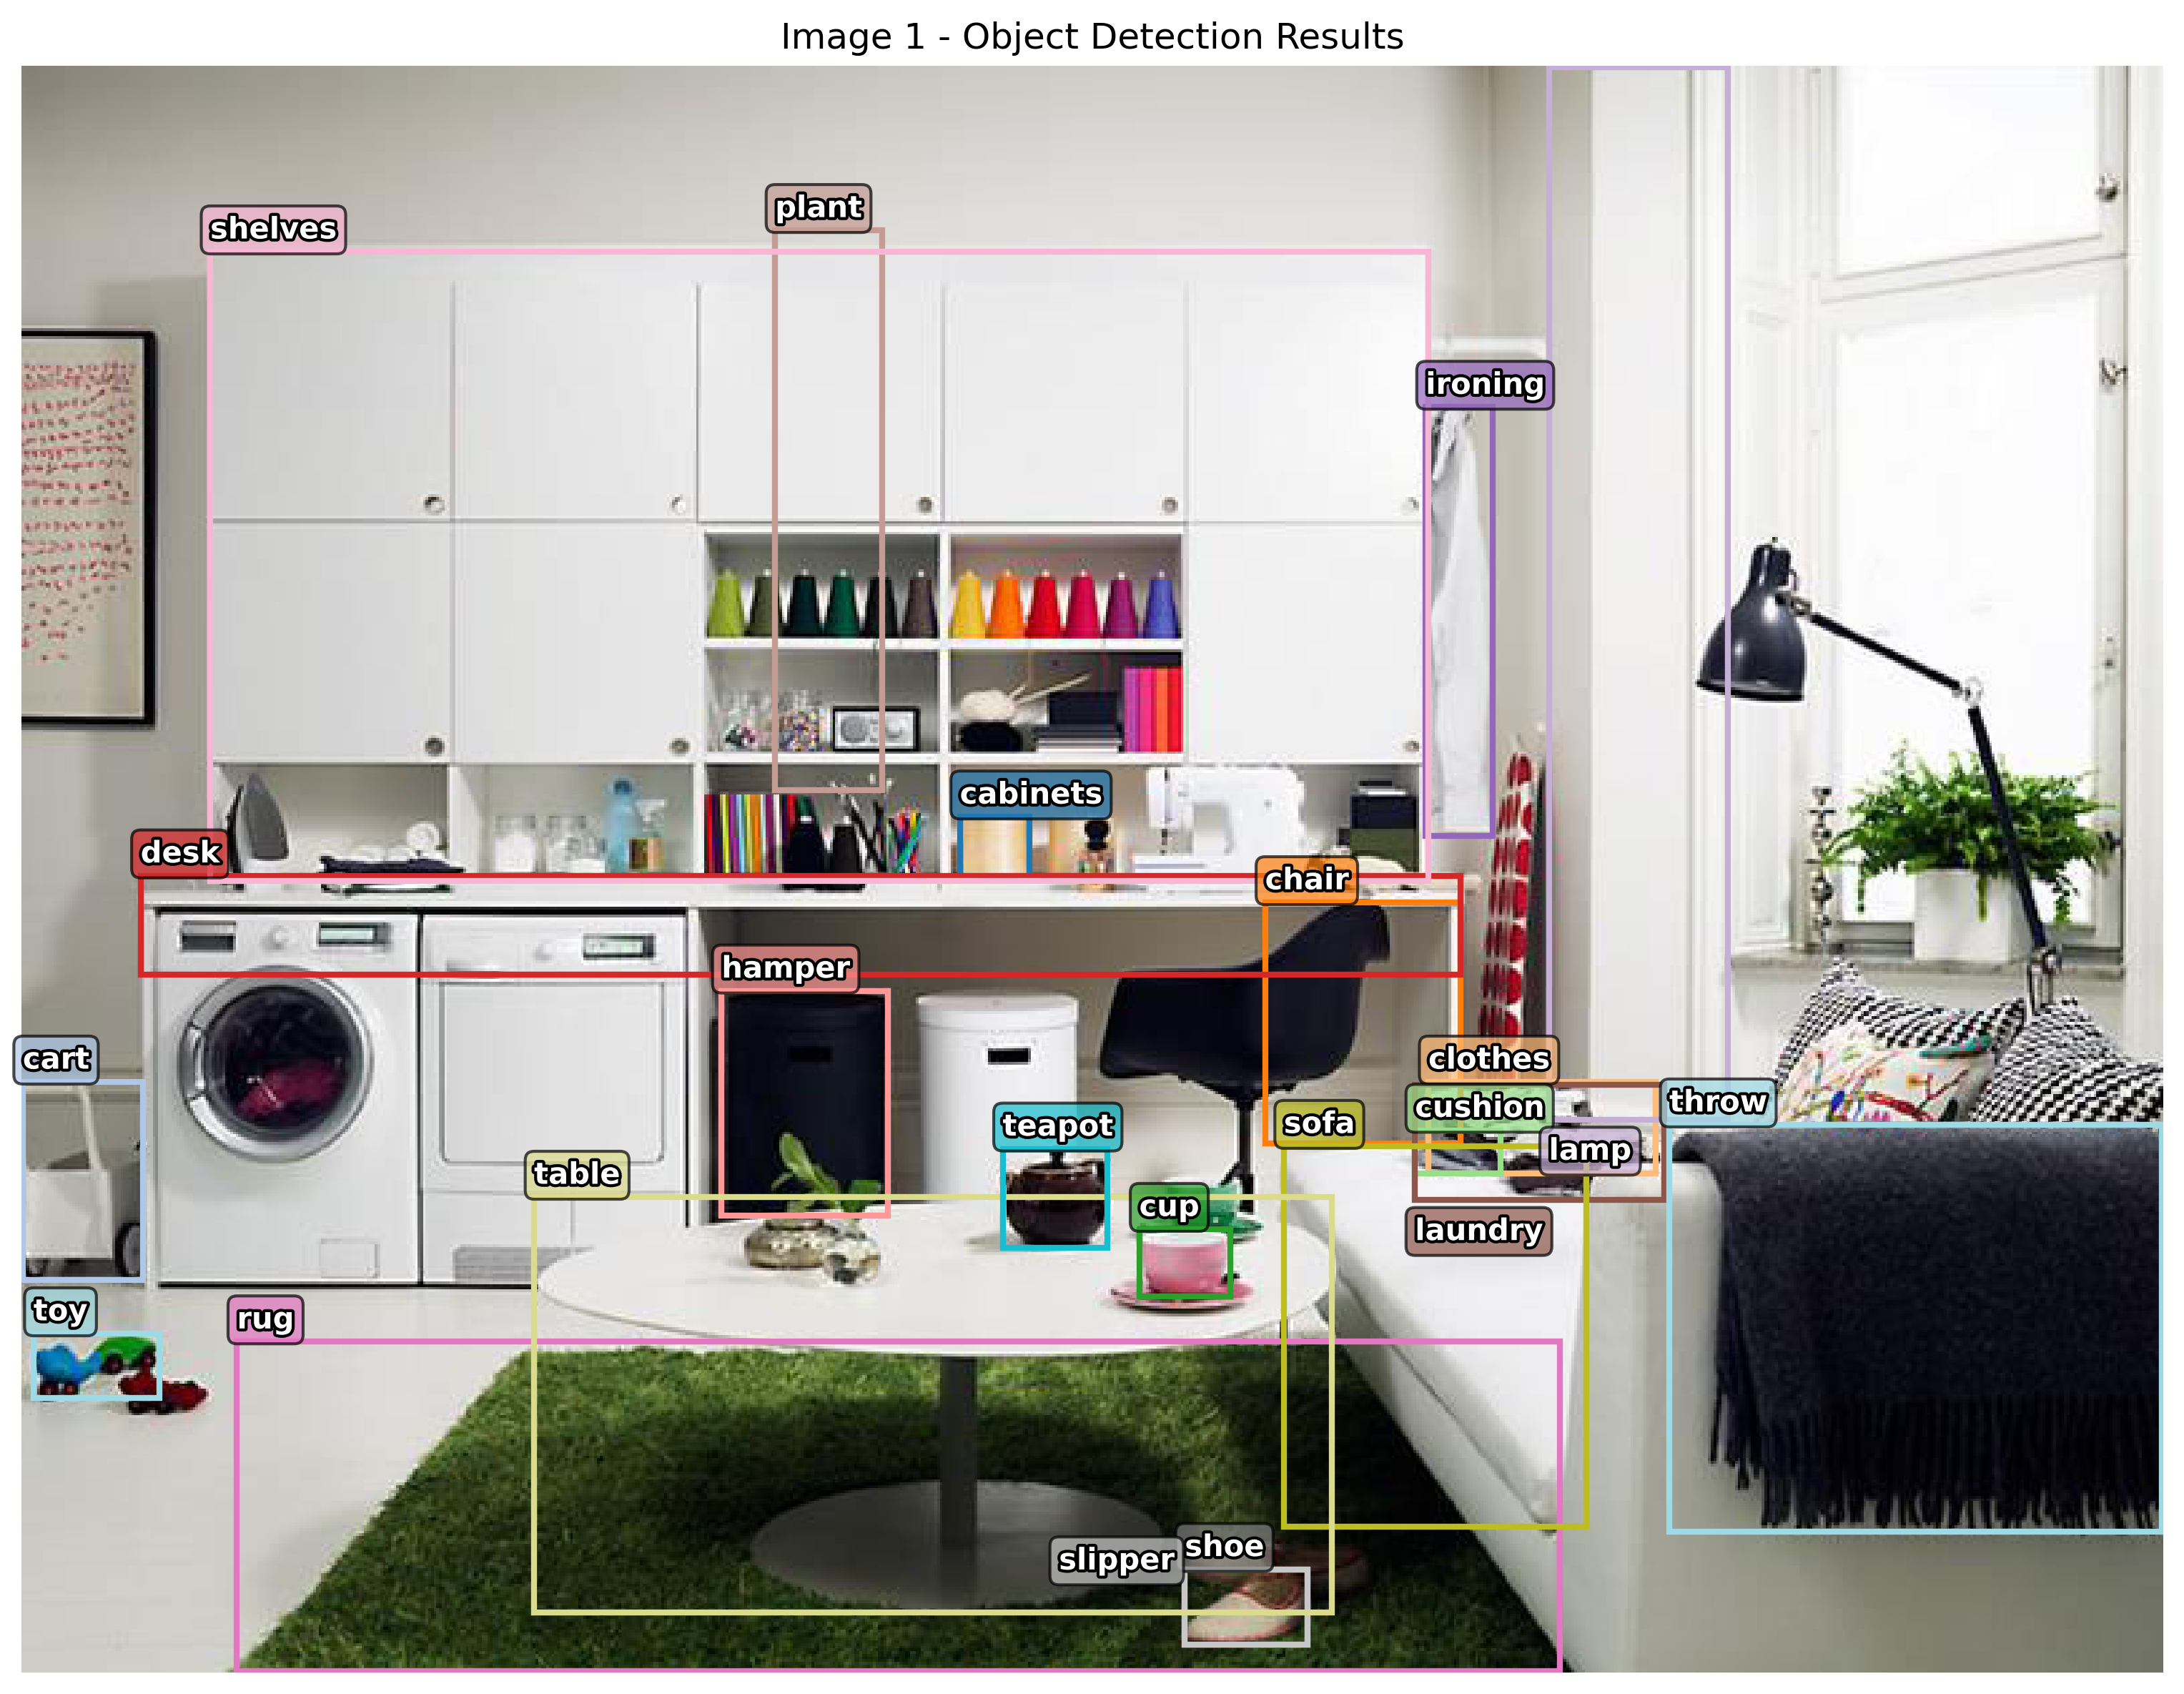

array([[[134, 130, 118],
        [133, 129, 117],
        [133, 129, 117],
        ...,
        [231, 232, 227],
        [235, 236, 230],
        [239, 240, 234]],

       [[134, 130, 118],
        [133, 129, 117],
        [133, 129, 117],
        ...,
        [231, 232, 227],
        [235, 236, 230],
        [239, 240, 234]],

       [[134, 130, 118],
        [134, 130, 118],
        [133, 129, 117],
        ...,
        [231, 232, 227],
        [235, 236, 230],
        [239, 240, 234]],

       ...,

       [[206, 205, 200],
        [206, 205, 200],
        [206, 205, 200],
        ...,
        [112, 114, 100],
        [112, 114, 100],
        [112, 114, 100]],

       [[206, 205, 200],
        [206, 205, 200],
        [206, 205, 200],
        ...,
        [112, 114, 100],
        [112, 114, 100],
        [112, 114, 100]],

       [[206, 205, 200],
        [206, 205, 200],
        [206, 205, 200],
        ...,
        [112, 114, 100],
        [112, 114, 100],
        [112, 114, 100]]

In [7]:
image_data.plot_masks( bbox_dict )

In [9]:
image_data.masks

In [ ]:
image_data.plot_mask_details()

In [8]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)

In [7]:
KG_path = os.path.join(".", "outputs", "KnowledgeGraph", f"IMG_{IMG_ID}_{IMG_TYPE}_knowledge_graph.pkl")

In [14]:
encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']

for encoding in encodings:
    try:
        with open(KG_path, 'r', encoding=encoding) as file:
            data = file.read()
        print(f"Successfully read with {encoding} encoding")
        break
    except UnicodeDecodeError:
        print(f"Failed with {encoding}")
        continue

Failed with utf-8
Successfully read with latin-1 encoding


In [15]:
data

"\x80\x04\x95\x7f\x0c\x00\x00\x00\x00\x00\x00\x8c\x18networkx.classes.digraph\x94\x8c\x07DiGraph\x94\x93\x94)\x81\x94}\x94(\x8c\x05graph\x94}\x94\x8c\x05_node\x94}\x94(\x8c\x0fWashing Machine\x94}\x94\x8c\x05Dryer\x94}\x94\x8c\x10Storage Cabinets\x94}\x94\x8c\x04Desk\x94}\x94\x8c\x05Chair\x94}\x94\x8c\x0cCoffee Table\x94}\x94\x8c\x04Sofa\x94}\x94\x8c\x03Rug\x94}\x94\x8c\x04Lamp\x94}\x94\x8c\x0bSmall Plant\x94}\x94\x8c\x0bLarge Plant\x94}\x94\x8c\x10Decorative Items\x94}\x94\x8c\tArt Piece\x94}\x94\x8c\x05White\x94}\x94\x8c\x05Black\x94}\x94\x8c\x08Circular\x94}\x94\x8c\x05Green\x94}\x94\x8c\x05Mixed\x94}\x94\x8c\x07Laundry\x94}\x94\x8c\x07Storage\x94}\x94\x8c\tWorkspace\x94}\x94\x8c\x07Seating\x94}\x94\x8c\nHolding_items\x94}\x94\x8c\nRelaxation\x94}\x94\x8c\nAdding_warmth\x94}\x94\x8c\x06Plants\x94}\x94\x8c\nAesthetics\x94}\x94\x8c\x08Lighting\x94}\x94\x8c\nDecoration\x94}\x94\x8c\x0bRectangular\x94}\x94\x8c\x14Long_and_Rectangular\x94}\x94\x8c\tErgonomic\x94}\x94\x8c\x05Round\x94}\x9